<a href="https://colab.research.google.com/github/noahdjroton/Sentiment_Analysis_Product_Reviews/blob/main/Sentiment_Analysis_Product_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup and Library Imports

In [1]:
!unzip Dataset.zip

Archive:  Dataset.zip
 extracting: Dataset/test-product-review.parquet  
 extracting: Dataset/train-product-review.parquet  


In [3]:
!pip install pyarrow

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Dataset Loading

In [8]:
train = pd.read_parquet("Dataset/train-product-review.parquet")
test = pd.read_parquet("Dataset/test-product-review.parquet")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (20000, 8)
Test shape: (1500, 8)


,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category
0,fr_0392802,product_fr_0863151,reviewer_fr_0127593,2,"Décevant, la qualité du son de ce vinyle est p...",moyen,fr,other
1,fr_0774965,product_fr_0516058,reviewer_fr_0836878,3,Les caractéristiques inscrites semblent identi...,produit reçu dans un autre emballage que sur l...,fr,musical_instruments
2,en_0364619,product_en_0917407,reviewer_en_0530306,5,Great smell and tasting tea. Love the box too.,Definitely a guest or anytime tea.,en,grocery
3,de_0437491,product_de_0932077,reviewer_de_0360484,4,Druck etwas pixelig. Sonst schickes Set,Schönes Set,de,toy
4,fr_0557442,product_fr_0993213,reviewer_fr_0009081,2,Le disque 6 était défectueux et j'ai perdu 15 ...,Un peu déçu,fr,other


In [9]:
test.head()

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category
0,fr_0775481,product_fr_0022150,reviewer_fr_0798224,3,Bon produit me renvoyer car cela taille petit,Bon produit,fr,sports
1,en_0254382,product_en_0280038,reviewer_en_0627235,2,Well I haven't stunned anyone...yet. So I can ...,Bad carry case,en,sports
2,de_0599684,product_de_0127768,reviewer_de_0303525,1,Lieferung super schnell allerdings tat sich na...,Schnelle Lieferung aber defekt,de,pc
3,de_0327211,product_de_0631850,reviewer_de_0509373,5,Farbe wie beschrieben und die Größe passt auch...,Passt,de,shoes
4,de_0541393,product_de_0472241,reviewer_de_0210077,2,Akku lässt sich leicht gegen den Originalen ta...,Eigentlich nicht mit den Originalen zu verglei...,de,home_improvement


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_id         20000 non-null  object
 1   product_id        20000 non-null  object
 2   reviewer_id       20000 non-null  object
 3   stars             20000 non-null  int32 
 4   review_body       20000 non-null  object
 5   review_title      20000 non-null  object
 6   language          20000 non-null  object
 7   product_category  20000 non-null  object
dtypes: int32(1), object(7)
memory usage: 1.1+ MB


## 3. Exploratory Data Analysis

In [12]:
train.isnull().sum()

,0
review_id,0
product_id,0
reviewer_id,0
stars,0
review_body,0
review_title,0
language,0
product_category,0


In [13]:
train["stars"].value_counts().sort_index()

,count
stars,
1,4059
2,3960
3,4006
4,3968
5,4007


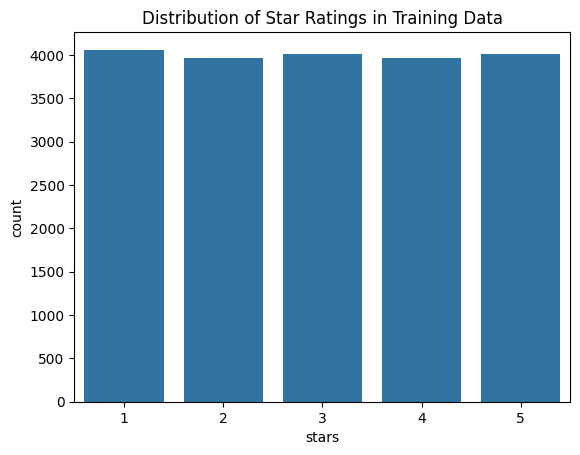

In [14]:
sns.countplot(data=train, x="stars")
plt.title("Distribution of Star Ratings in Training Data")
plt.show()

In [15]:
train["language"].value_counts()

,count
language,
en,6736
de,6634
fr,6630


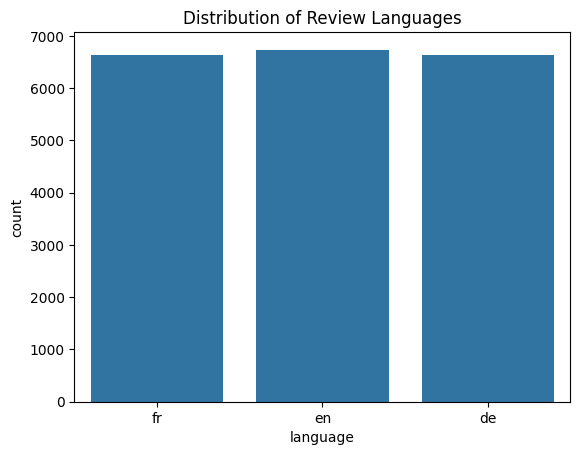

In [16]:
sns.countplot(data=train, x="language")
plt.title("Distribution of Review Languages")
plt.show()

In [17]:
train["product_category"].value_counts().head(10)

,count
product_category,
home,2457
wireless,1976
home_improvement,1111
apparel,1043
toy,1028
sports,1022
beauty,908
drugstore,893
other,817


## 4. Sentiment Label Creation

In [20]:
def map_sentiment(stars):
    if stars <= 2:
        return "Negative"
    elif stars == 3:
        return "Neutral"
    else:
        return "Positive"

train["sentiment"] = train["stars"].apply(map_sentiment)
test["sentiment"] = test["stars"].apply(map_sentiment)

In [21]:
train["sentiment"].value_counts()

,count
sentiment,
Negative,8019
Positive,7975
Neutral,4006


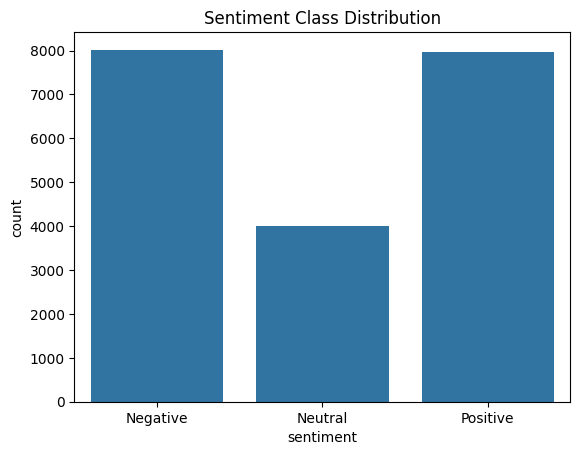

In [22]:
sns.countplot(data=train, x="sentiment", order=["Negative", "Neutral", "Positive"])
plt.title("Sentiment Class Distribution")
plt.show()

## 5. Text Feature Preparation

In [24]:
train["text"] = train["review_title"].astype(str) + " " + train["review_body"].astype(str)
test["text"] = test["review_title"].astype(str) + " " + test["review_body"].astype(str)

X_train = train["text"]
y_train = train["sentiment"]

X_test = test["text"]
y_test = test["sentiment"]

In [25]:
X_train.head()

,text
0,"moyen Décevant, la qualité du son de ce vinyle..."
1,produit reçu dans un autre emballage que sur l...
2,Definitely a guest or anytime tea. Great smell...
3,Schönes Set Druck etwas pixelig. Sonst schicke...
4,Un peu déçu Le disque 6 était défectueux et j'...


## 6. Model 1: TF-IDF with Logistic Regression

In [27]:
model_lr = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("classifier", LogisticRegression(max_iter=1000))
])

model_lr.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                ('classifier', LogisticRegression(max_iter=1000))])

In [28]:
y_pred_lr = model_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7473333333333333
              precision    recall  f1-score   support

    Negative       0.77      0.85      0.81       596
     Neutral       0.48      0.29      0.37       292
    Positive       0.79      0.86      0.83       612

    accuracy                           0.75      1500
   macro avg       0.68      0.67      0.67      1500
weighted avg       0.72      0.75      0.73      1500



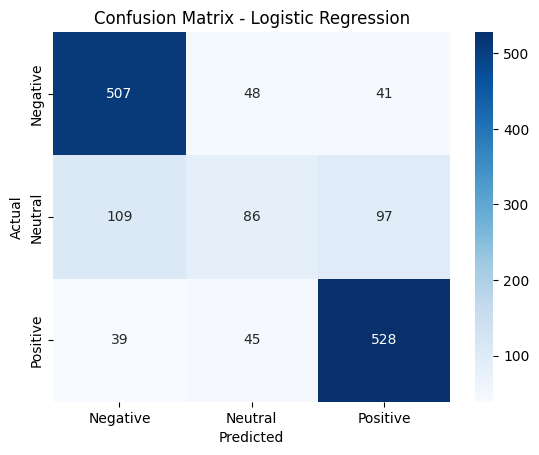

In [29]:
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=["Negative", "Neutral", "Positive"])

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Interpretation of Logistic Regression Results

The Logistic Regression model achieved an accuracy of 0.747. It performed well on the Negative and Positive classes, with F1-scores of 0.81 and 0.83. However, the Neutral class was more difficult to predict, with an F1-score of 0.37.

This shows that the model can identify clear positive and negative opinions quite well, but it struggles when the review is more balanced or ambiguous. Overall, this model gives good results and is simple to understand.

## 7. Model 2: TF-IDF with Multi-Layer Perceptron

In [31]:
model_mlp = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("classifier", MLPClassifier(hidden_layer_sizes=(100,), max_iter=10, random_state=42))
])

model_mlp.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                ('classifier', MLPClassifier(max_iter=10, random_state=42))])

In [32]:
y_pred_mlp = model_mlp.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

Accuracy: 0.696
              precision    recall  f1-score   support

    Negative       0.78      0.74      0.76       596
     Neutral       0.39      0.41      0.40       292
    Positive       0.77      0.79      0.78       612

    accuracy                           0.70      1500
   macro avg       0.65      0.65      0.65      1500
weighted avg       0.70      0.70      0.70      1500



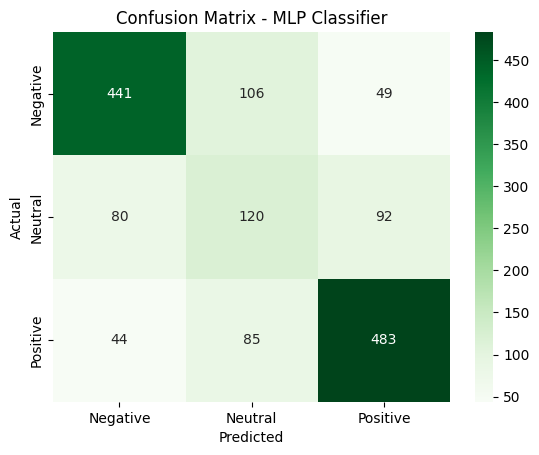

In [33]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp, labels=["Negative", "Neutral", "Positive"])

sns.heatmap(cm_mlp, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MLP Classifier")
plt.show()

### Interpretation of MLP Classifier Results

The MLP Classifier achieved an accuracy of 0.696, which is lower than the Logistic Regression model. It performed reasonably well on the Negative and Positive classes, but it also had difficulty with the Neutral class.

The MLP model improved the F1-score for Neutral slightly compared with Logistic Regression, but its overall accuracy and weighted average scores were lower. This means that the neural network did not clearly outperform the classical model in this experiment.

## 8. Model Comparison

In [35]:
from sklearn.metrics import precision_recall_fscore_support

def get_metrics(y_true, y_pred, model_name):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro"
    )
    accuracy = accuracy_score(y_true, y_pred)
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1-score": f1
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_lr, "TF-IDF + Logistic Regression"),
    get_metrics(y_test, y_pred_mlp, "TF-IDF + MLP Classifier")
])

results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score
0,TF-IDF + Logistic Regression,0.747333,0.682429,0.669312,0.667341
1,TF-IDF + MLP Classifier,0.696000,0.646807,0.646702,0.646418


## 9. Error Analysis

### Error Analysis Interpretation

The error analysis shows that many mistakes happen with Neutral reviews. This is expected because neutral reviews can include both positive and negative comments. For example, a customer may like one part of a product but dislike another part. This makes the sentiment harder to classify.

Some errors may also be linked to the multilingual nature of the dataset. The same model is learning from English, French, and German reviews, which makes the task more complex.

In [37]:
error_analysis = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted_lr": y_pred_lr,
    "predicted_mlp": y_pred_mlp
})

lr_errors = error_analysis[error_analysis["actual"] != error_analysis["predicted_lr"]]

lr_errors.head(10)

,text,actual,predicted_lr,predicted_mlp
0,Bon produit Bon produit me renvoyer car cela t...,Neutral,Positive,Positive
2,Schnelle Lieferung aber defekt Lieferung super...,Negative,Positive,Positive
7,attention taille grand pour un 41 prendre un 40,Neutral,Negative,Negative
13,Conforme à la description. Sac en toile person...,Neutral,Positive,Positive
17,"Nothing spectacular, but a good value for the ...",Neutral,Positive,Positive
18,Easy read Good storyline but the characterizat...,Neutral,Positive,Neutral
19,Gewohnte Qualität Gewohnte Qualität von Bosch ...,Positive,Negative,Negative
21,Nothing different from the rest... Never notic...,Neutral,Positive,Positive
23,Pas top Attention vraiment sa fait plastique c...,Negative,Positive,Neutral
25,"Satisfaite du chariot Il est facile à monter, ...",Positive,Neutral,Positive


## 10. Conclusion

This project compared two machine learning approaches for product review sentiment classification: TF-IDF with Logistic Regression and TF-IDF with an MLP Classifier. The goal was to classify reviews as Negative, Neutral, or Positive.

The Logistic Regression model achieved the best overall performance, with an accuracy of 0.747. The MLP Classifier achieved a lower accuracy of 0.696. Based on these results, Logistic Regression was the most suitable model for this task because it was more accurate, simpler, and easier to interpret.

Both models performed better on Negative and Positive reviews than on Neutral reviews. This is probably because neutral reviews are more difficult to classify. A neutral review can contain both positive and negative words, so the sentiment is less clear.

The main limitations of this project are the multilingual dataset and the use of TF-IDF. TF-IDF does not fully understand the meaning or context of words. In the future, the system could be improved by using more advanced multilingual models such as BERT or XLM-RoBERTa, and by testing more hyperparameters.